1.5_4: HARISS inf imputed=0; rows=1000
2.0_4: HARISS inf imputed=0; rows=1000
=== 1.5_4 === AWW_CTT1 mean 33.035
=== 2.0_4 === AWW_CTT1 mean 24.008


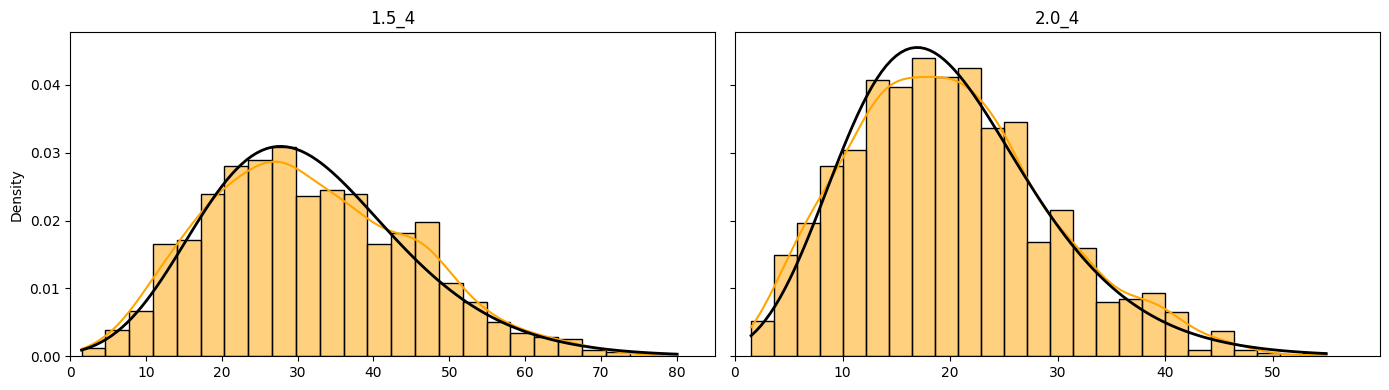

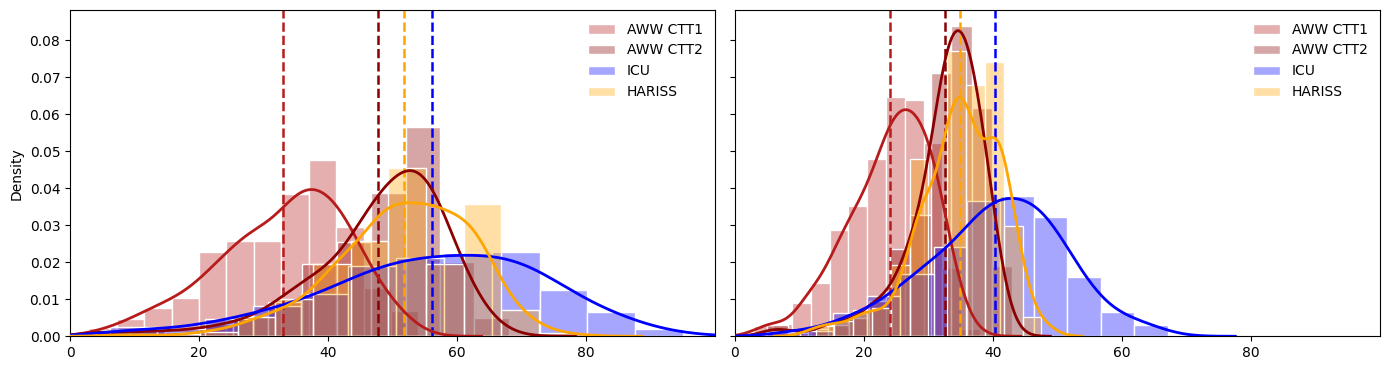

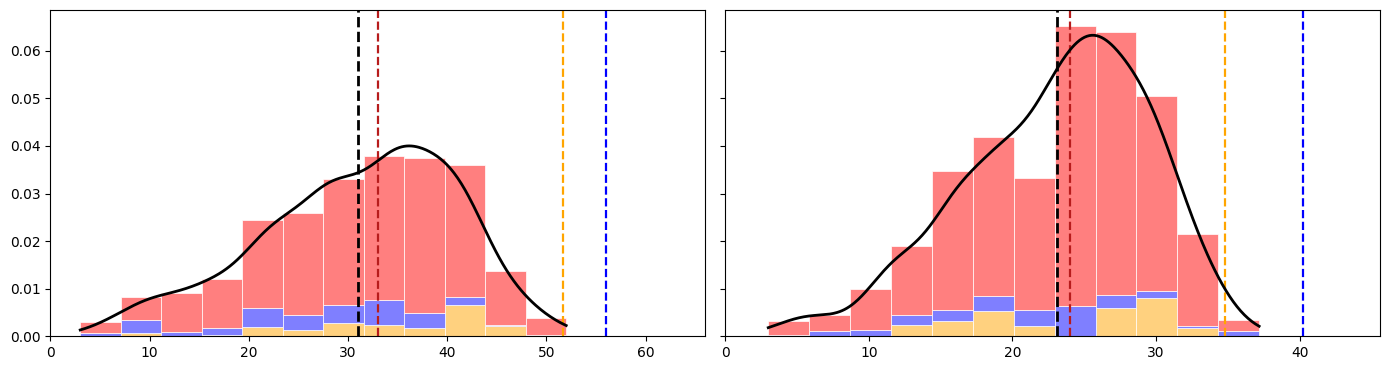

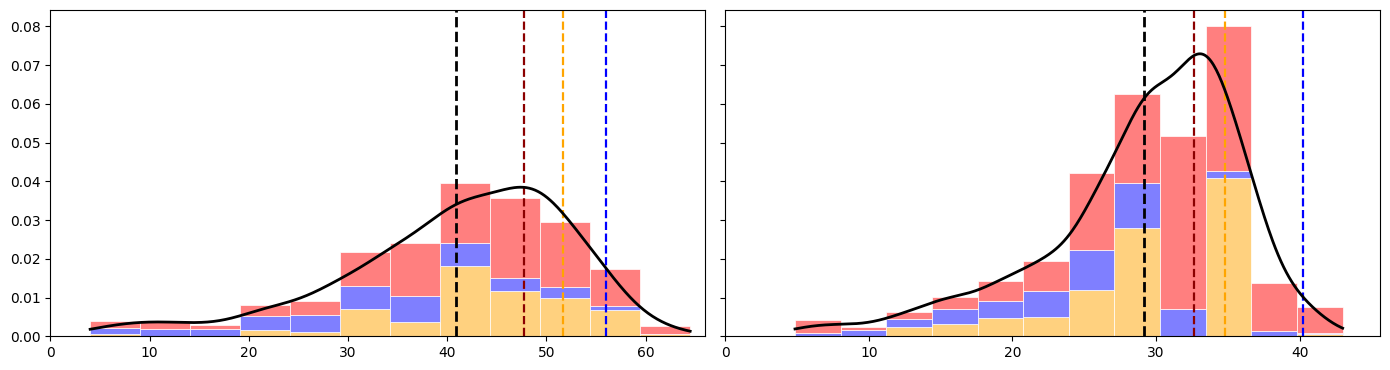

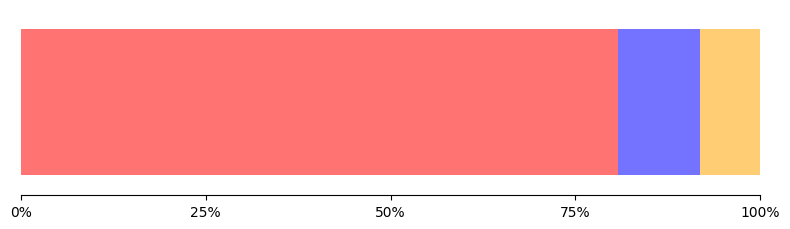

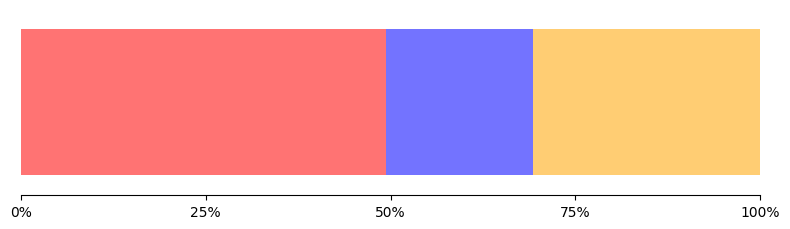

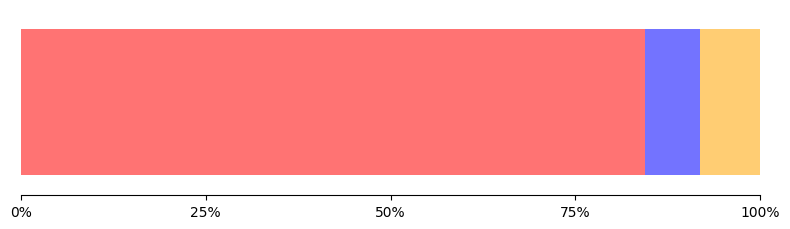

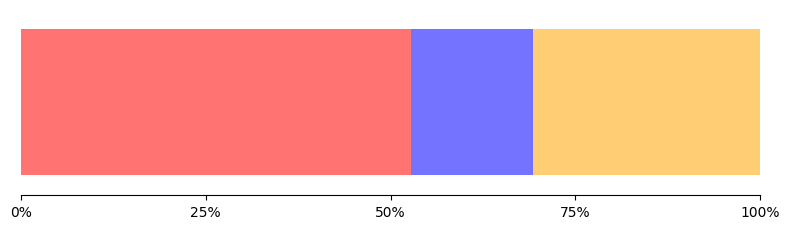

In [39]:
# CTT multitype: compare 1.5_4 vs 2.0_4 side-by-side (shared y per row); four separate bar plots (pct x-axis).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path

_ROOT = Path("/Users/reddy/AWW_and_ICU/global_model/pgfgleam/all_results/local/")
_SAVE_DIR = Path("/Users/reddy/AWW_and_ICU/global_model")
_LABELS = ("1.5_4", "2.0_4")


def load_ctt(suffix):
    p = _ROOT / f"multitype_comparison_samples_ctt_{suffix}.csv"
    assert p.is_file(), f"CSV not found: {p}"
    df = pd.read_csv(p)
    df = df[df["hariss_detection_time"] < np.inf]
    df = df[df["aww_ctt2_detection_time"] < np.inf]
    _n_inf = int(np.isinf(df["hariss_detection_time"].to_numpy()).sum())
    ok = df[np.isfinite(df["hariss_detection_time"])]
    if len(ok) > 0:
        cap = 7.0 + float(ok["hariss_detection_time"].max())
        df = df.copy()
        df.loc[np.isinf(df["hariss_detection_time"]), "hariss_detection_time"] = cap
    print(f"{suffix}: HARISS inf imputed={_n_inf}; rows={len(df)}")
    return df


def arrays_from(df):
    def _f(x):
        a = np.asarray(pd.to_numeric(x, errors="coerce"), dtype=float)
        return a[np.isfinite(a)]

    c1, c2, ic, ha = (
        _f(df["aww_ctt1_detection_time"]),
        _f(df["aww_ctt2_detection_time"]),
        _f(df["icu_detection_time"]),
        _f(df["hariss_detection_time"]),
    )
    return {"c1": c1, "c2": c2, "ic": ic, "ha": ha, "t_all": np.r_[c1, c2, ic, ha], "df": df}


def differences_from(df):
    d = []
    for _, row in df.iterrows():
        mx = max(
            row["aww_ctt1_detection_time"],
            row["aww_ctt2_detection_time"],
            row["icu_detection_time"],
            row["hariss_detection_time"],
        )
        d.append(float(mx) - float(row["earliest_detection_time_ctt1"]))
    return np.asarray(d)


def kde_line(ax, vals):
    vals = vals[np.isfinite(vals)]
    if vals.size < 2:
        return
    kde = stats.gaussian_kde(vals)
    x0, x1 = float(vals.min()), float(vals.max())
    xs = np.linspace(x0, x1, 400)
    ax.plot(xs, kde(xs), color="black", lw=2, zorder=5)


_CTT1_COL, _CTT2_COL = "#B71C1C", "#8B0000"
type_colors = {"AWW": "red", "ICU": "blue", "HARISS": "orange"}
_N_BINS = 12

by = {lb: arrays_from(load_ctt(lb)) for lb in _LABELS}

# Earliest panels: x-range from *earliest* detection times only (what the histogram plots), not channel max.
# Max over CTT1 & CTT2 earliest columns per scenario so both rows (ctt1 vs ctt2 PDFs) align for 1.5_4 / 2.0_4.
_EARLY_PAD = 5.0
_xr_early = {}
for lb in _LABELS:
    d = by[lb]["df"]
    e1 = pd.to_numeric(d["earliest_detection_time_ctt1"], errors="coerce")
    e2 = pd.to_numeric(d["earliest_detection_time_ctt2"], errors="coerce")
    _xr_early[lb] = float(np.nanmax(np.r_[e1.to_numpy(), e2.to_numpy()])) + _EARLY_PAD

qlo, qhi = 0.025, 0.975
for lb in _LABELS:
    d = by[lb]["df"]
    print(f"=== {lb} === AWW_CTT1 mean", float(d["aww_ctt1_detection_time"].mean()))


def _style_pct_x(bax):
    bax.set_xlim(0, 1)
    bax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    bax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
    bax.tick_params(axis="y", left=False, labelleft=False)
    bax.tick_params(axis="x", bottom=True, labelbottom=True)
    for s in ["left", "right", "top"]:
        bax.spines[s].set_visible(False)
    bax.set_xlabel("Share (%)")


# —— Row 1: max − earliest spread ——
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, lb in zip(axes.flat, _LABELS):
    diff = differences_from(by[lb]["df"])
    fit = stats.lognorm.fit(diff)
    xp = np.linspace(float(np.min(diff)), float(np.max(diff)), 120)
    sns.histplot(diff, ax=ax, bins=25, color="orange", stat="density", kde=True)
    ax.plot(xp, stats.lognorm.pdf(xp, *fit), "k", lw=2)
    ax.set_xlim(0, float(np.max(diff)) + 5.0)
    ax.set_ylabel("Density" if lb == _LABELS[0] else "")
    ax.set_title(lb)
plt.tight_layout()
plt.savefig(_SAVE_DIR / "figure6_row_diff.pdf", dpi=300, bbox_inches="tight")
plt.show()

# —— Row 2: four detection-time channels —— same x-axis for both scenarios (easy to compare ICU/HARISS etc. lines)
_xr_four = float(max(np.max(by[lb]["t_all"]) for lb in _LABELS)) + 5.0
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True, sharex=True)
for ax, lb in zip(axes.flat, _LABELS):
    A = by[lb]
    c1, c2, ic, ha = A["c1"], A["c2"], A["ic"], A["ha"]
    hist_kw = dict(bins=_N_BINS, edgecolor="white", alpha=0.35, kde=False, stat="density")
    for arr, col, lab in [(c1, _CTT1_COL, "AWW CTT1"), (c2, _CTT2_COL, "AWW CTT2"), (ic, "blue", "ICU"), (ha, "orange", "HARISS")]:
        sns.histplot(arr, ax=ax, color=col, label=lab, **hist_kw)
    x_clip = (0.0, _xr_four)
    for arr, col in [(c1, _CTT1_COL), (c2, _CTT2_COL), (ic, "blue"), (ha, "orange")]:
        sns.kdeplot(arr, ax=ax, color=col, lw=2.0, clip=x_clip, bw_adjust=1.3, zorder=5)
    ax.axvline(c1.mean(), color=_CTT1_COL, ls="--", lw=1.8)
    ax.axvline(c2.mean(), color=_CTT2_COL, ls="--", lw=1.8)
    ax.axvline(ic.mean(), color="blue", ls="--", lw=1.8)
    ax.axvline(ha.mean(), color="orange", ls="--", lw=1.8)
    ax.set_ylabel("Density" if lb == _LABELS[0] else "")
    ax.set_xlabel("")
    hdl, labs = ax.get_legend_handles_labels()
    ax.legend(dict(zip(labs, hdl)).values(), dict(zip(labs, hdl)).keys(), loc="upper right", frameon=False)
axes[0].set_xlim(0, _xr_four)
plt.tight_layout()
plt.savefig(_SAVE_DIR / "figure6_row_fourchan.pdf", dpi=300, bbox_inches="tight")
plt.show()


def earliest_pair(which):
    xkey = "earliest_detection_time_ctt1" if which == "ctt1" else "earliest_detection_time_ctt2"
    hkey = "earliest_surveillance_type_ctt1" if which == "ctt1" else "earliest_surveillance_type_ctt2"
    title = "Earliest (CTT1)" if which == "ctt1" else "Earliest (CTT2)"
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True)
    for ax, lb in zip(axes.flat, _LABELS):
        df = by[lb]["df"]
        sub = df[[xkey, hkey]].dropna(subset=[xkey, hkey])
        sub = sub[np.isfinite(sub[xkey])]
        sns.histplot(
            data=sub,
            x=xkey,
            hue=hkey,
            hue_order=["AWW", "ICU", "HARISS"],
            palette=type_colors,
            multiple="stack",
            bins=_N_BINS,
            ax=ax,
            stat="density",
            edgecolor="white",
            linewidth=0.5,
            alpha=0.5,
        )
        t = sub[xkey].to_numpy(dtype=float)
        kde_line(ax, t)
        ax.axvline(np.mean(t), color="black", ls="--", lw=2)
        A = by[lb]
        if which == "ctt1":
            ax.axvline(A["c1"].mean(), color=_CTT1_COL, ls="--", lw=1.6)
        else:
            ax.axvline(A["c2"].mean(), color=_CTT2_COL, ls="--", lw=1.6)
        ax.axvline(A["ic"].mean(), color="blue", ls="--", lw=1.6)
        ax.axvline(A["ha"].mean(), color="orange", ls="--", lw=1.6)
        ax.set_xlim(0, 0.95*_xr_early[lb])
        ax.set_ylabel("")
        ax.set_xlabel("")
        lg = ax.get_legend()
        if lg is not None:
            lg.remove()
    plt.tight_layout()
    plt.savefig(_SAVE_DIR / f"figure6_row_{which}.pdf", dpi=300, bbox_inches="tight")
    plt.show()


earliest_pair("ctt1")
earliest_pair("ctt2")

# Four separate bar plots: % x-axis only (ticks 0/25/50/75/100), no y
for suf in _LABELS:
    for ctt_which, tag in [("ctt1", "CTT1"), ("ctt2", "CTT2")]:
        col = f"earliest_surveillance_type_{ctt_which}"
        s = by[suf]["df"][col].value_counts().reindex(["AWW", "ICU", "HARISS"], fill_value=0)
        s = s / s.sum()
        fig, bax = plt.subplots(figsize=(8, 2.4))
        left = 0.0
        for k, v in s.items():
            bax.barh(0, v, left=left, color=type_colors[k], alpha=0.55, height=0.55)
            left += v
        bax.set_ylim(-0.35, 0.35)
        _style_pct_x(bax)
        bax.set_xlabel("")
        plt.tight_layout()
        outp = _SAVE_DIR / f"bars_{suf}_{tag}.pdf"
        plt.savefig(outp, dpi=300, bbox_inches="tight")
        plt.show()
